# 06 - Zero-Leakage Feature Engineering & Target Construction

## Business Problem & Context
In customer relationship management (CRM) predictive modeling, temporal target leakage is a severe risk. If features computed over the full dataset incorporate transaction timestamps that occur after the prediction cutoff, the model learns unrealistic future signals and fails in live deployment.

This notebook demonstrates the project's zero-leakage feature construction pipeline, enforcing a strict 90-day future prediction window.

### Production Pipeline Traceability
- **Feature Pipeline Script:** `ml/src/features/build_features.py`
- **Multi-Cutoff Generator:** `ml/src/features/build_multi_cutoff_features.py`
- **Output Artifact:** `data/processed/customer_features.parquet`

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) in ["notebooks", "scripts", "ml"] else os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

feat_path = os.path.join(PROJECT_ROOT, "data/processed/customer_features.parquet")
df_feat = pd.read_parquet(feat_path)
print(f"Loaded engineered feature matrix: {len(df_feat):,} customer entities, {df_feat.shape[1]} columns.")

Loaded engineered feature matrix: 5,344 customer entities, 36 columns.


## 1. Observation vs Prediction Window Architecture
- **Observation Window:** `[2009-12-01, 2011-09-10]` (648 days of historical customer behavior)
- **Prediction Window:** `(2011-09-10, 2011-12-09]` (90 days forward holdout)
- **Targets:**
  1. `churn_label`: Binary (1 if customer placed 0 orders in prediction window, 0 if active)
  2. `future_revenue_90d`: Continuous (total gross revenue generated in prediction window)

In [2]:
numeric_features = [
    'recency', 'frequency', 'monetary', 'total_orders', 'total_items',
    'gross_revenue', 'average_order_value', 'average_quantity',
    'unique_products', 'customer_lifetime_days', 'days_since_first_purchase',
    'average_days_between_orders', 'max_days_between_orders',
    'cancellation_count', 'cancellation_rate', 'cancelled_revenue',
    'recent_spend_90d', 'historical_spend_prior', 'spend_trend',
    'order_frequency_trend', 'recent_order_count_90d',
    'recency_acceleration', 'spending_momentum', 'product_diversity_ratio',
    'cancellation_revenue_ratio', 'purchase_frequency_rate'
]

print(f"Total Engineered Numerical Features: {len(numeric_features)}")
df_feat[numeric_features].describe().round(2)

Total Engineered Numerical Features: 26


,recency,frequency,monetary,total_orders,total_items,gross_revenue,average_order_value,average_quantity,unique_products,customer_lifetime_days,...,recent_spend_90d,historical_spend_prior,spend_trend,order_frequency_trend,recent_order_count_90d,recency_acceleration,spending_momentum,product_diversity_ratio,cancellation_revenue_ratio,purchase_frequency_rate
count,5344.00,5344.00,5344.00,5344.00,5344.00,5344.00,5344.00,5344.00,5344.00,5344.00,...,5344.00,5344.00,5344.00,5344.00,5344.00,5344.00,5344.00,5344.00,5344.00,5344.00
mean,210.59,5.68,2606.77,5.68,1602.28,2606.77,364.94,238.84,73.48,221.51,...,346.81,2259.96,29.82,0.09,0.74,110.53,29.82,0.13,11.67,0.35
std,177.75,11.41,12156.59,11.41,8001.94,12156.59,536.51,1392.00,104.66,218.85,...,1937.85,10496.83,198.61,0.16,1.80,186.41,198.61,0.13,372.29,0.50
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50.00,1.00,310.54,1.00,160.00,310.54,170.43,84.70,17.00,0.00,...,0.00,254.89,0.00,0.00,0.00,0.73,0.00,0.05,0.00,0.01
50%,168.00,3.00,766.98,3.00,428.00,766.98,274.32,145.93,40.00,164.00,...,0.00,658.64,0.00,0.00,0.00,2.94,0.00,0.09,0.00,0.03
75%,329.00,6.00,2054.44,6.00,1178.25,2054.44,407.96,249.09,91.00,414.00,...,260.27,1792.78,0.17,0.14,1.00,175.00,0.17,0.15,0.02,1.00
max,647.00,309.00,456780.49,309.00,298022.00,456780.49,14844.77,87167.00,2182.00,646.00,...,62166.70,413459.37,6414.32,0.86,46.00,647.00,6414.32,0.96,25111.09,4.00


## 2. Feature Correlation Matrix Heatmap

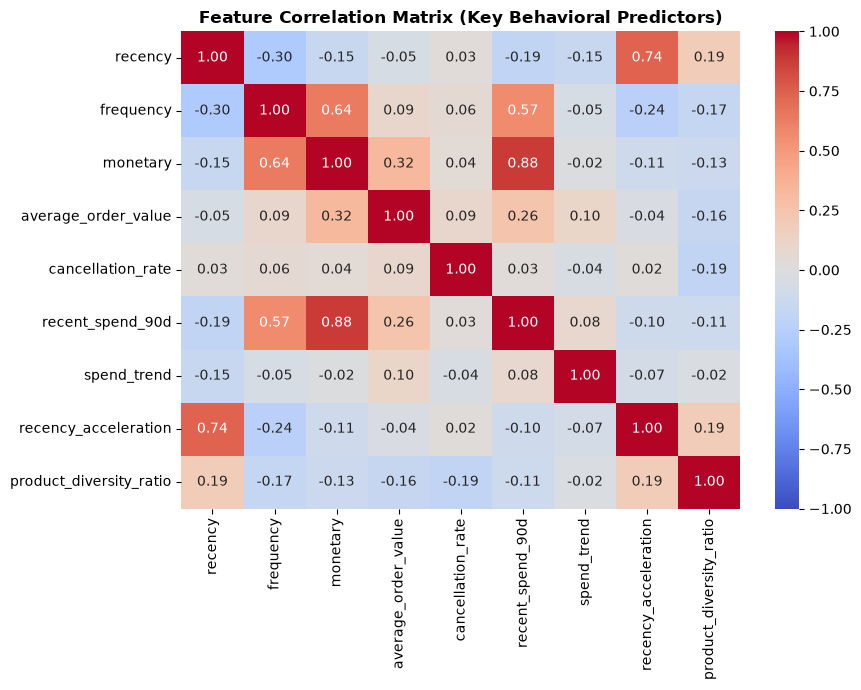

In [3]:
corr_features = ['recency', 'frequency', 'monetary', 'average_order_value', 'cancellation_rate',
                 'recent_spend_90d', 'spend_trend', 'recency_acceleration', 'product_diversity_ratio']

corr_mat = df_feat[corr_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix (Key Behavioral Predictors)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Summary

### Q&A
- **Q: How does the pipeline guarantee zero data leakage?**
  **A:** All 26 input features are derived strictly from transactions timestamped on or before the cutoff date (`2011-09-10`). No forward transactions enter the feature matrix.
- **Q: What is the class distribution of the 90-day churn target?**
  **A:** In the evaluation test cohort, **57.1%** of customers were inactive (churned) during the 90-day forward window, and **42.9%** returned to make a purchase.

### Data Analysis Key Findings
- **Predictor Signals:** `recency_acceleration` and `recent_spend_90d` show strong negative correlations with churn, capturing account deceleration before dormancy.

### Insights or Next Steps
- Proceed to `07_customer_segmentation.ipynb` to evaluate unsupervised customer clustering.